Dataset shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']

── Accuracy ─────────────────────────────
Test accuracy: 0.9667

── Classification Report ────────────────
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


── Confusion Matrix ─────────────────────
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

── Tree Structure (text) ────────────────
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.65
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.65
|   |   |--- petal length (cm) <= 4.85
| 

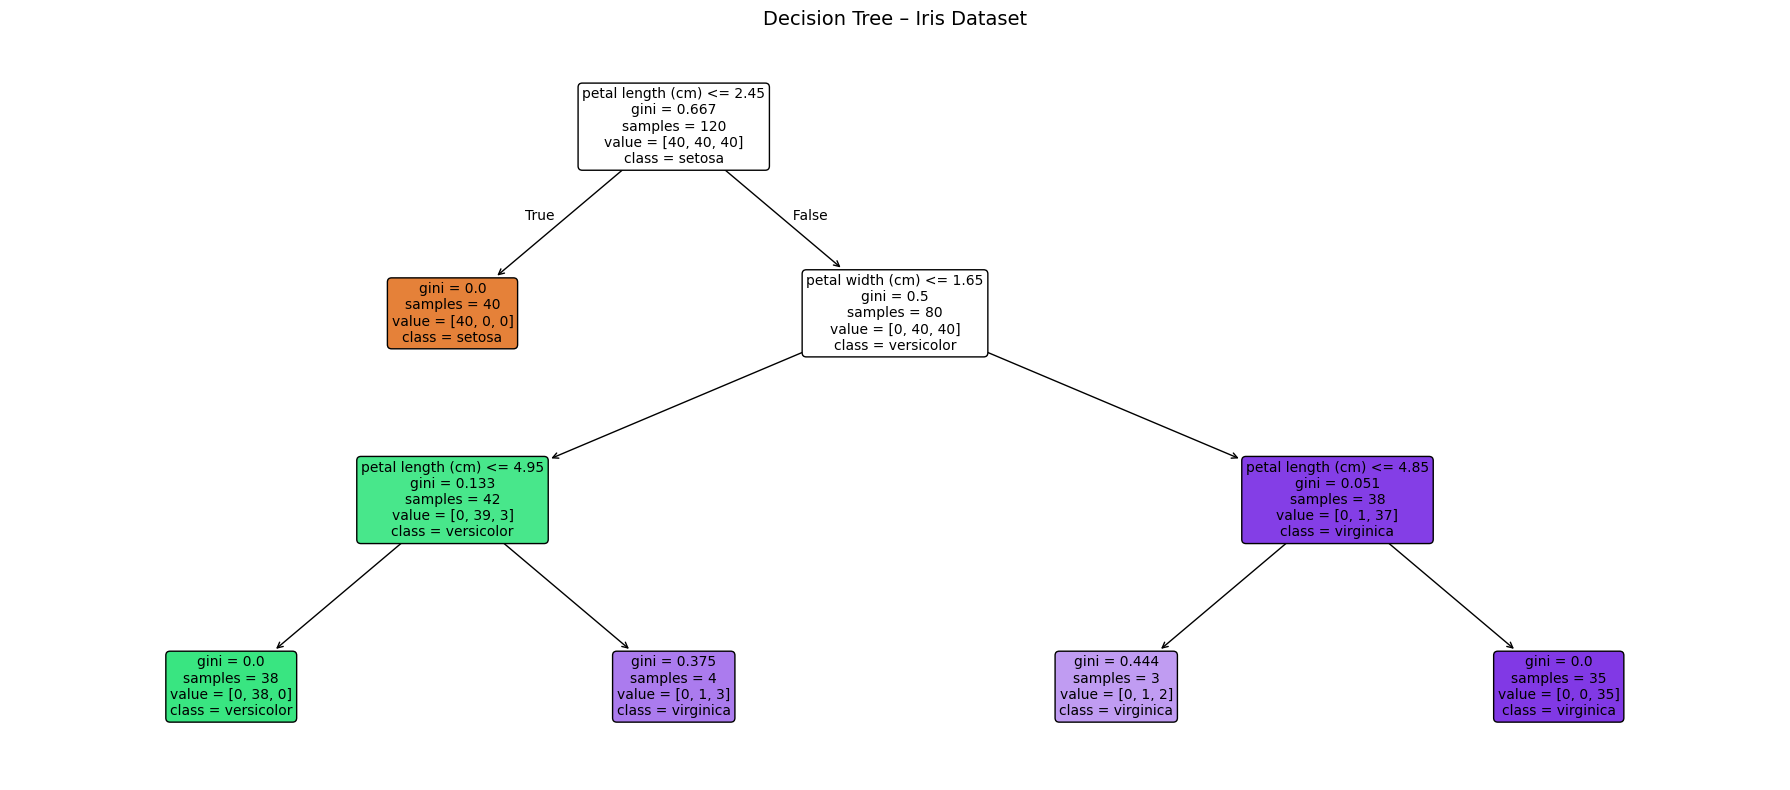


── Predictions for new samples ──────────
  Sample 1: setosa        Probabilities: {np.str_('setosa'): np.float64(1.0), np.str_('versicolor'): np.float64(0.0), np.str_('virginica'): np.float64(0.0)}
  Sample 2: virginica     Probabilities: {np.str_('setosa'): np.float64(0.0), np.str_('versicolor'): np.float64(0.0), np.str_('virginica'): np.float64(1.0)}


In [1]:
"""
Decision Tree Classifier using scikit-learn
--------------------------------------------
Demonstrates: training, evaluation, visualization, and prediction.
Uses the classic Iris dataset as an example.
"""

import numpy as np
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt


# ── 1. Load data ──────────────────────────────────────────────────────────────
data = load_iris()
X, y = data.data, data.target
feature_names = data.feature_names
class_names = data.target_names

print("Dataset shape:", X.shape)
print("Classes:", class_names)

# ── 2. Split into train / test ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 3. Train the Decision Tree ────────────────────────────────────────────────
clf = DecisionTreeClassifier(
    criterion="gini",       # "gini" or "entropy"
    max_depth=4,            # Limit depth to avoid overfitting; set None for full tree
    min_samples_split=5,    # Min samples required to split a node
    min_samples_leaf=2,     # Min samples required at a leaf node
    random_state=42,
)
clf.fit(X_train, y_train)

# ── 4. Evaluate ───────────────────────────────────────────────────────────────
y_pred = clf.predict(X_test)

print("\n── Accuracy ─────────────────────────────")
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\n── Classification Report ────────────────")
print(classification_report(y_test, y_pred, target_names=class_names))

print("\n── Confusion Matrix ─────────────────────")
print(confusion_matrix(y_test, y_pred))

# ── 5. Print text representation of the tree ─────────────────────────────────
print("\n── Tree Structure (text) ────────────────")
print(export_text(clf, feature_names=feature_names))

# ── 6. Feature importances ────────────────────────────────────────────────────
print("── Feature Importances ──────────────────")
for name, importance in sorted(
    zip(feature_names, clf.feature_importances_), key=lambda x: -x[1]
):
    print(f"  {name:<30} {importance:.4f}")

# ── 7. Visualize the tree ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(
    clf,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,          # Color nodes by majority class
    rounded=True,
    fontsize=10,
    ax=ax,
)
plt.title("Decision Tree – Iris Dataset", fontsize=14)
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=150, bbox_inches="tight")
print("\nTree plot saved to decision_tree.png")
plt.show()

# ── 8. Predict on new samples ─────────────────────────────────────────────────
new_samples = np.array([
    [5.1, 3.5, 1.4, 0.2],   # Expected: setosa
    [6.7, 3.0, 5.2, 2.3],   # Expected: virginica
])
predictions = clf.predict(new_samples)
probabilities = clf.predict_proba(new_samples)

print("\n── Predictions for new samples ──────────")
for i, (pred, probs) in enumerate(zip(predictions, probabilities)):
    print(f"  Sample {i+1}: {class_names[pred]:<12}  "
          f"Probabilities: {dict(zip(class_names, probs.round(2)))}")